In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ATTENTION_FILE = "store_lstm_attention_reg_weights.parquet"
ATTENTION_PATH = Path(f"../outputs/attention/{ATTENTION_FILE}")

df = pd.read_parquet(ATTENTION_PATH)
df['datetime'] = df['datetime'].sort_values(ascending=True)
print(df.shape)
df.head()

(20186, 27)


,city_id,datetime,attn_t_minus_24,attn_t_minus_23,attn_t_minus_22,attn_t_minus_21,attn_t_minus_20,attn_t_minus_19,attn_t_minus_18,attn_t_minus_17,...,attn_t_minus_9,attn_t_minus_8,attn_t_minus_7,attn_t_minus_6,attn_t_minus_5,attn_t_minus_4,attn_t_minus_3,attn_t_minus_2,attn_t_minus_1,model
0,0,2024-06-12 15:00:00,0.193005,0.074185,0.048314,0.049063,0.034412,0.013359,0.002253,0.002760,...,0.040111,0.004247,0.003871,0.012483,0.036568,0.062805,0.051080,0.061053,0.104073,store_lstm_attention_reg
1,0,2024-06-12 15:00:00,0.322115,0.147208,0.075711,0.059473,0.030588,0.005259,0.000666,0.003471,...,0.058964,0.005822,0.000306,0.000092,0.000757,0.008422,0.023391,0.035416,0.043301,store_lstm_attention_reg
2,0,2024-06-12 15:00:00,0.202260,0.089525,0.042704,0.046981,0.032158,0.010713,0.002727,0.003177,...,0.058606,0.003943,0.000447,0.000887,0.008598,0.038339,0.052975,0.046854,0.053933,store_lstm_attention_reg
3,0,2024-06-12 15:00:00,0.229714,0.153840,0.030625,0.050106,0.026255,0.005281,0.001608,0.002207,...,0.040913,0.001474,0.000174,0.000761,0.011416,0.038626,0.060720,0.059814,0.044815,store_lstm_attention_reg
4,0,2024-06-12 15:00:00,0.232921,0.061259,0.095313,0.049213,0.063488,0.035193,0.005385,0.002397,...,0.067737,0.015571,0.000840,0.000147,0.000490,0.005581,0.029792,0.059957,0.084297,store_lstm_attention_reg


In [27]:
attention_cols = [col for col in df.columns if col.startswith("attn_")]

df[attention_cols].sum(axis=1).head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float32

In [28]:
row = df.loc[0]
forecast_time = row["datetime"]

attn_readable = pd.DataFrame({
    "lag": list(range(24, 0, -1)),
    "past_datetime": [forecast_time - pd.Timedelta(hours=i) for i in range(24, 0, -1)],
    "attention_weight": row[attention_cols].values
})

attn_readable.sort_values("attention_weight", ascending=False).head(10)

,lag,past_datetime,attention_weight
21,3,2024-06-12 12:00:00,0.194942
22,2,2024-06-12 13:00:00,0.193386
23,1,2024-06-12 14:00:00,0.186896
20,4,2024-06-12 11:00:00,0.185523
19,5,2024-06-12 10:00:00,0.136369
18,6,2024-06-12 09:00:00,0.062768
17,7,2024-06-12 08:00:00,0.031267
16,8,2024-06-12 07:00:00,0.008103
15,9,2024-06-12 06:00:00,0.000645
14,10,2024-06-12 05:00:00,0.000051


<Axes: title={'center': 'Average attention weight by past hour'}, xlabel='lag'>

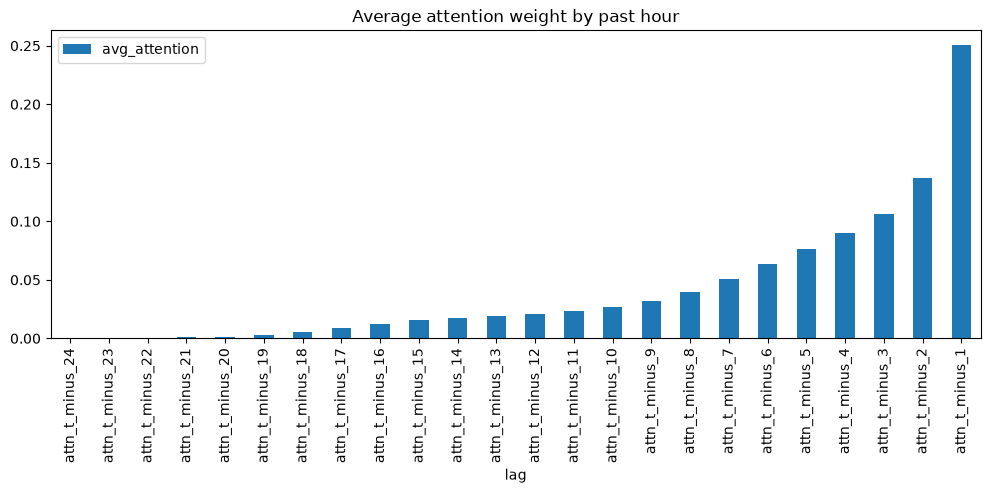

In [29]:
avg_attention = df[attention_cols].mean().reset_index()
avg_attention.columns = ["lag", "avg_attention"]

avg_attention["lag_num"] = avg_attention["lag"].str.extract(r"minus_(\d+)").astype(int)
avg_attention = avg_attention.sort_values("lag_num", ascending=False)

avg_attention.plot(
    x="lag",
    y="avg_attention",
    kind="bar",
    figsize=(12, 4),
    title="Average attention weight by past hour"
)